In [1]:
path = r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\parquet-data\lev-10\data\lev-10_merged.parquet"

# import 
import pandas as pd
import polars as pl
import missingno as msgo
import matplotlib.pyplot as plt
import seaborn as sns


# Import Data and filter
pdf = pl.read_parquet(path)
display(f"Before Filtering the shape {pdf.shape}")
pdf = pdf.filter(
    pl.col('State') == '23'
)
display(f"After Filter the shape {pdf.shape}")

# ------------------------ Our useful variables are 
# ===============================

cols = [
'Item_Code_12_series',
'OOHP_Quantity_12_series',
'OOHP_Value_12_series',
'Total_Consumption_Quantity_12_se',
'Total_Consumption_Value_12_serie',
]

pdf = pdf[cols]

display(f"Desire Filter shape {pdf.shape}")

# str -> int 
pdf = pdf.with_columns(
    [pl.col(col).cast(pl.Int16, strict=False) for col in pdf.columns]
)

display(pdf.schema)

'Before Filtering the shape (1658620, 25)'

'After Filter the shape (125912, 25)'

'Desire Filter shape (125912, 5)'

Schema([('Item_Code_12_series', Int16),
        ('OOHP_Quantity_12_series', Int16),
        ('OOHP_Value_12_series', Int16),
        ('Total_Consumption_Quantity_12_se', Int16),
        ('Total_Consumption_Value_12_serie', Int16)])

In [6]:
colors = ['#cb17eb','#A4EB17', '#17EBC8', '#EB173A', '#ffde59']  
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

palette = ['#cb17eb','#A4EB17', '#17EBC8', '#EB173A', '#ffde59', '#ccff33', '#ff36ab', '#e0fbfc', '#3772ff', '#45062e']  
sns.set_palette(palette)

In [2]:
pdf['Item_Code_12_series'].unique().to_list()

[300,
 301,
 302,
 309,
 310,
 311,
 312,
 313,
 314,
 315,
 316,
 317,
 319,
 320,
 321,
 322,
 323,
 324,
 325,
 329]

In [5]:
mapping = {
    300: "pan: leaf (no.)",
    301: "pan: finished (no.)",
    302: "ingredients for pan (gm)",
    309: "pan: sub-total",
    310: "bidi (no.)",
    311: "cigarettes (no.)",
    316: "gutka, zarda, kimam, surti (gm)",
    312: "leaf tobacco (gm)",
    314: "hookah tobacco (gm)",
    315: "cheroot (no.)",
    313: "snuff (gm)",
    317: "other tobacco products",
    319: "tobacco: sub-total",
    322: "country liquor (litre)",
    324: "foreign/refined liquor or wine (litre)",
    323: "beer (litre)",
    321: "toddy (litre)",
    320: "ganja (gm)",
    325: "other intoxicants",
    329: "intoxicants: sub-total",
}

In [9]:
df = pdf.to_pandas()
df['Map_item'] = df['Item_Code_12_series'].map(mapping)

In [10]:
df.columns

Index(['Item_Code_12_series', 'OOHP_Quantity_12_series',
       'OOHP_Value_12_series', 'Total_Consumption_Quantity_12_se',
       'Total_Consumption_Value_12_serie', 'Map_item'],
      dtype='object')

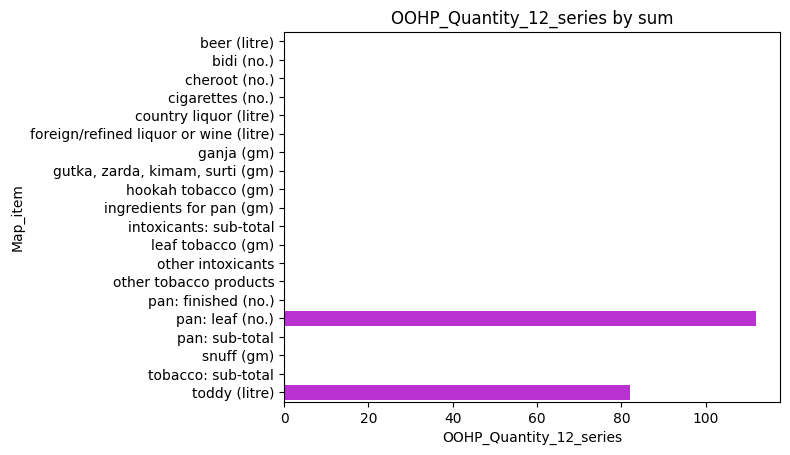

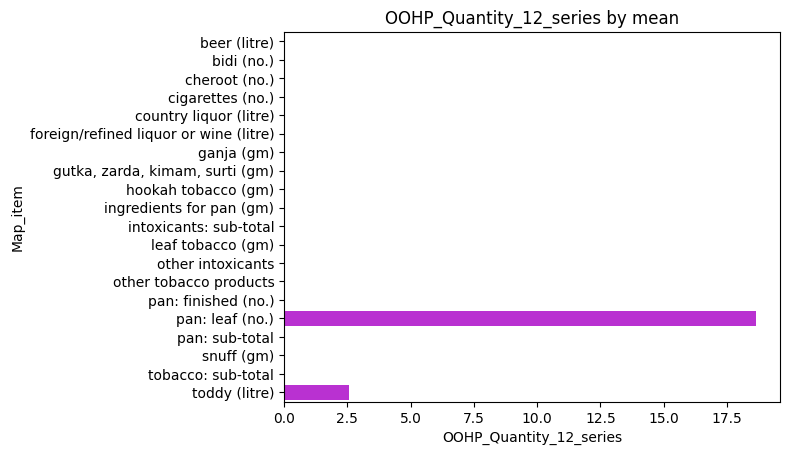

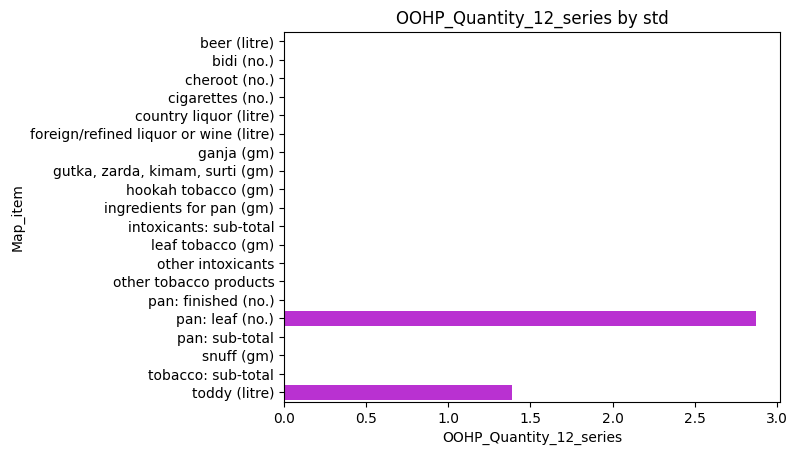

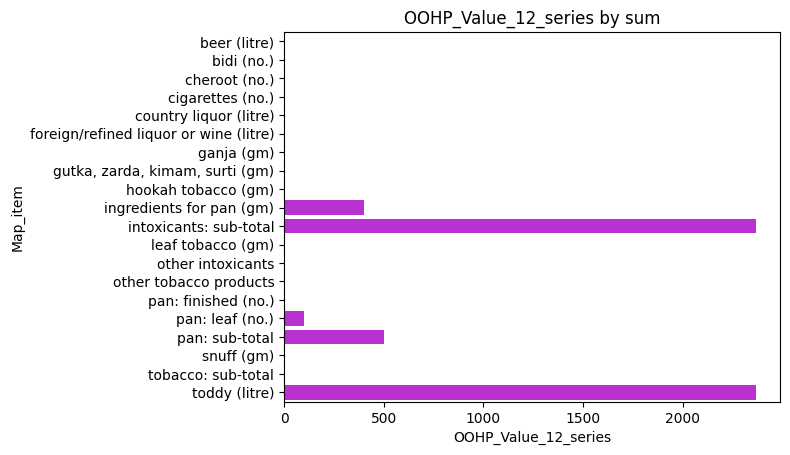

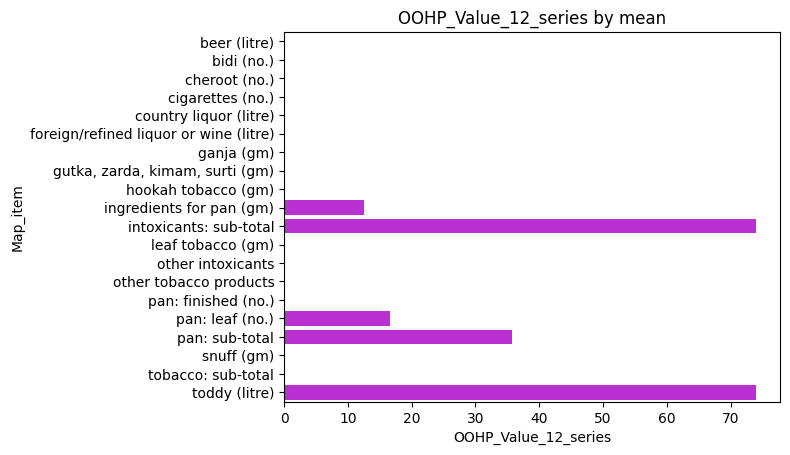

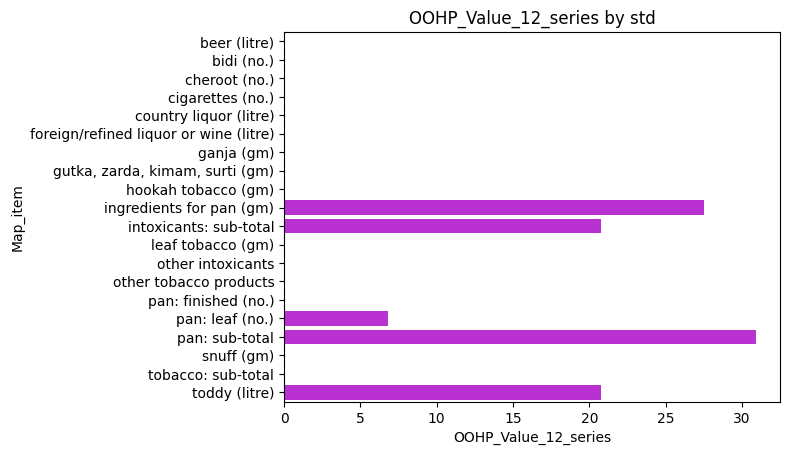

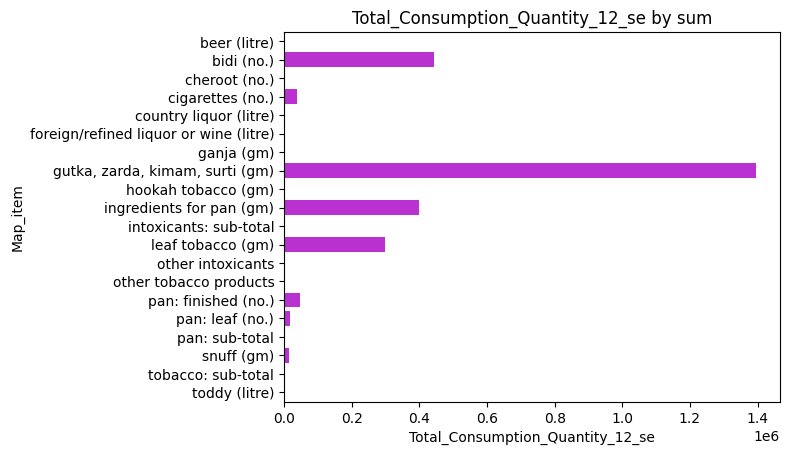

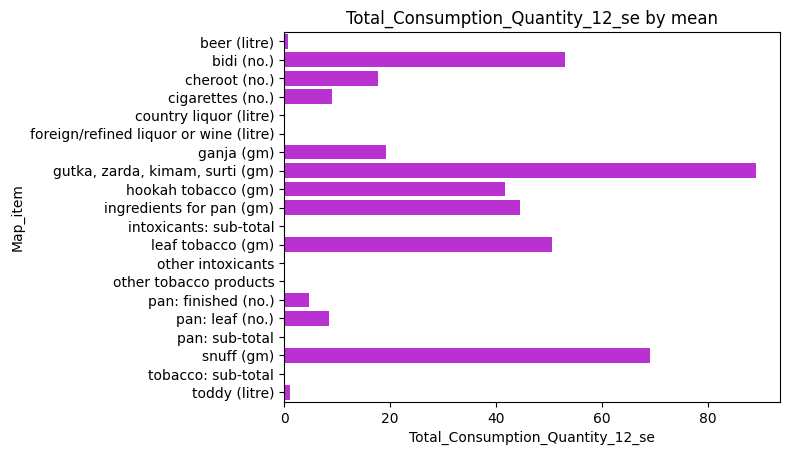

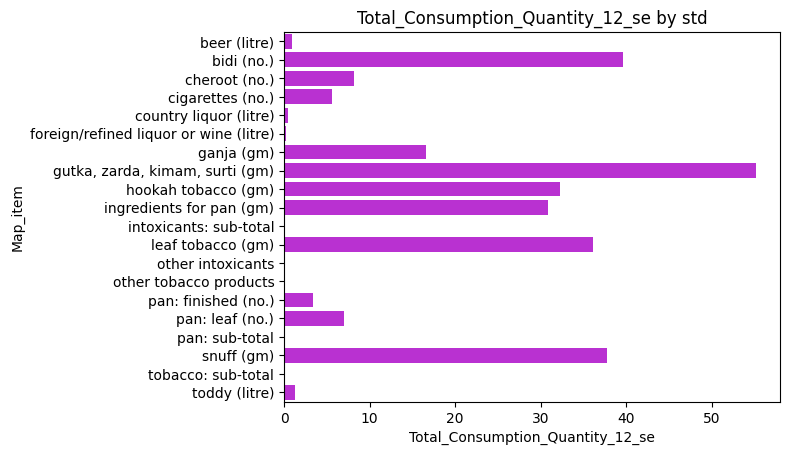

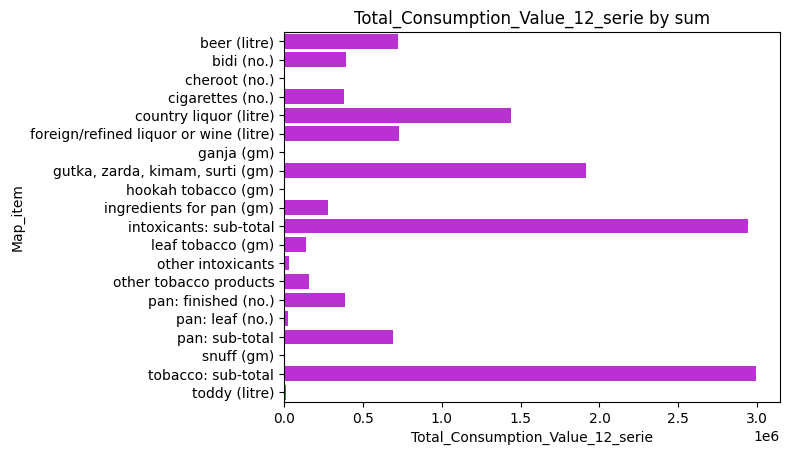

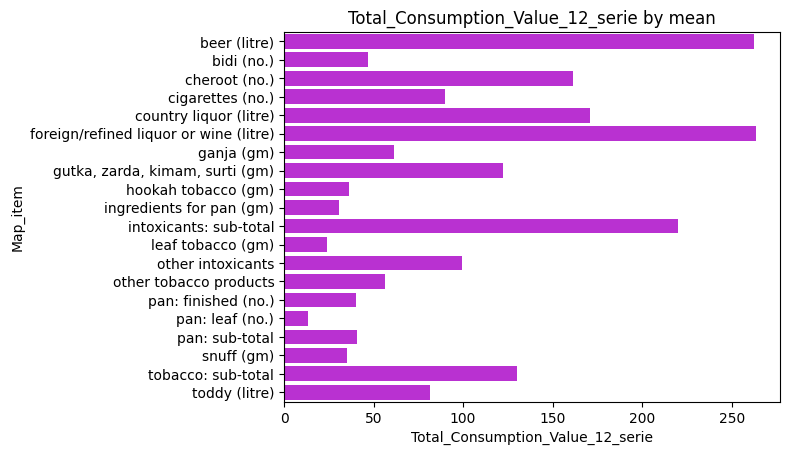

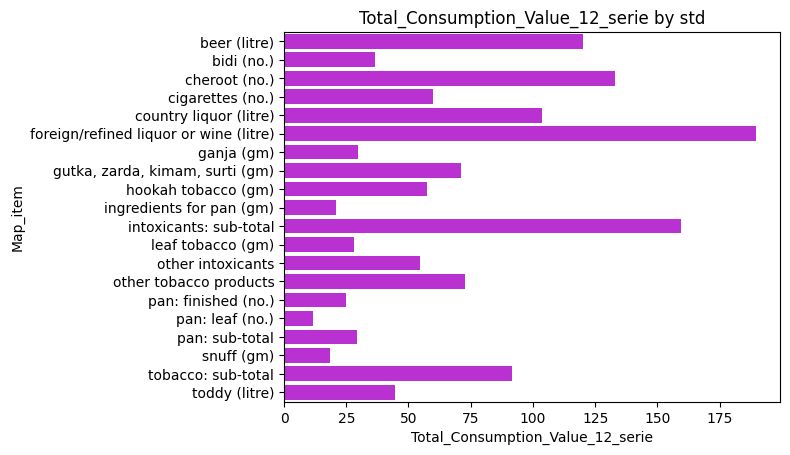

In [12]:
columns = ['OOHP_Quantity_12_series','OOHP_Value_12_series',
           'Total_Consumption_Quantity_12_se', 'Total_Consumption_Value_12_serie']

agg_functions = ['sum', 'mean', 'std']

for col in columns:
       for fun in agg_functions:
              sns.barplot(df.groupby('Map_item')[col].agg(fun), orient='h')
              plt.title(f"{col} by {fun}")
              plt.show()